In [1]:
!pip install -q transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.1 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

In [2]:
from kaggle_secrets import UserSecretsClient
import os
os.environ['HF_TOKEN'] = UserSecretsClient().get_secret('HF_TOKEN')

In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

tokenizer_llama = AutoTokenizer.from_pretrained(MODEL_ID, token=os.environ['HF_TOKEN'])
model_llama = AutoModelForCausalLM.from_pretrained(
  MODEL_ID,
  torch_dtype=torch.bfloat16,
  device_map="auto",
  token=os.environ['HF_TOKEN'],
)
model_llama.eval()
print(f'Zaladowano {MODEL_ID} na {model_llama.device}')

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Zaladowano Qwen/Qwen2.5-3B-Instruct na cuda:0


In [5]:
import os, zipfile, urllib.request
import pandas as pd

DATA_DIR = "/kaggle/working/data"
os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(os.path.join(DATA_DIR, "test.tsv")):
  urllib.request.urlretrieve(
      "https://www.cs.ucsb.edu/~william/data/liar_dataset.zip",
      os.path.join(DATA_DIR, "liar.zip"))
  with zipfile.ZipFile(os.path.join(DATA_DIR, "liar.zip")) as z:
      z.extractall(DATA_DIR)

COLUMNS = ["id","label","statement","subject","speaker","job_title","state","party",
         "barely_true_counts","false_counts","half_true_counts","mostly_true_counts",
         "pants_on_fire_counts","context"]

def load_split(name):
  df = pd.read_csv(os.path.join(DATA_DIR, f"{name}.tsv"), sep="\t", header=None, names=COLUMNS)
  return df

train_raw = load_split("train")
test_raw  = load_split("test")

def combine_text(row):
  speaker = row.get("speaker") if pd.notna(row.get("speaker")) else "unknown"
  party   = row.get("party")   if pd.notna(row.get("party"))   else "unknown"
  def _n(x):
      try:
          v = float(x); return 0 if pd.isna(v) else int(v)
      except (TypeError, ValueError): return 0
  lies   = _n(row.get("false_counts")) + _n(row.get("pants_on_fire_counts"))
  truths = _n(row.get("mostly_true_counts")) + _n(row.get("half_true_counts"))
  parts = [f"{speaker} ({party}, past lies: {lies}, past truths: {truths}): {row['statement']}"]
  if pd.notna(row.get("subject")): parts.append("Subject: " + str(row["subject"]))
  if pd.notna(row.get("context")): parts.append("Context: " + str(row["context"]))
  return " ".join(parts)

train_raw["combined"] = train_raw.apply(combine_text, axis=1)
test_raw["combined"]  = test_raw.apply(combine_text, axis=1)

LABELS_6 = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]
BIN_MAP = {"pants-fire":"fake","false":"fake","barely-true":"fake",
         "half-true":"real","mostly-true":"real","true":"real"}
LABELS_2 = ["fake", "real"]

def prep_split(df, num_classes):
  df = df[df["label"].isin(LABELS_6)].copy()
  if num_classes == 2:
      df["y_str"] = df["label"].map(BIN_MAP); labels = LABELS_2
  else:
      df["y_str"] = df["label"]; labels = LABELS_6
  df["y"] = df["y_str"].map({l:i for i,l in enumerate(labels)})
  return df.reset_index(drop=True), labels

print(f"train: {train_raw.shape}, test: {test_raw.shape}")

train: (10240, 15), test: (1267, 15)


In [14]:
import torch, json, time, re
from tqdm.auto import tqdm

LABELS_6 = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]
LABEL_DESC_6 = {
  "pants-fire":"razaco falszywe","false":"falszywe","barely-true":"mylace",
  "half-true":"czesciowo prawdziwe","mostly-true":"w wiekszosci prawdziwe","true":"prawdziwe",
}

def build_prompt(combined, labels):
  if len(labels) == 2:
      guide = ("- fake: the statement is false or mostly misleading\n"
               "- real: the statement is true or mostly true")
  else:
      guide = ("- pants-fire: blatantly false, ridiculous lie\n"
               "- false: false\n"
               "- barely-true: contains a grain of truth but significantly misleading\n"
               "- half-true: partially true, omits significant facts\n"
               "- mostly-true: mostly true, minor inaccuracies\n"
               "- true: true")
  label_list = ", ".join(labels)
  system = (f"You are a truth classifier for political statements from the LIAR dataset. "
            f"Assign EXACTLY one of these {len(labels)} labels:\n{guide}\n\n"
            f"Respond with ONLY the label, no explanation.")
  user = f"Statement: {combined}\n\nLabel:"
  return [
      {"role":"system","content":system},
      {"role":"user","content":user},
  ]

def parse_label(text, labels):
  if not text: return None
  t = text.strip().lower().strip(".,;:!?\"'`{} \n")
  if t in labels: return t
  for l in sorted(labels, key=len, reverse=True):
      if l in t: return l
  return None

@torch.no_grad()
def llama_classify(test_df, labels, batch_size=8, max_new=8):
  preds = []
  prompts = [tokenizer_llama.apply_chat_template(
      build_prompt(r["combined"], labels),
      tokenize=False, add_generation_prompt=True
  ) for _, r in test_df.iterrows()]

  for i in tqdm(range(0, len(prompts), batch_size)):
      batch = prompts[i:i+batch_size]
      inputs = tokenizer_llama(batch, return_tensors="pt", padding=True,
                                truncation=True, max_length=2048).to(model_llama.device)
      out = model_llama.generate(
          **inputs, max_new_tokens=max_new, do_sample=False,
          pad_token_id=tokenizer_llama.eos_token_id,
      )
      gen = out[:, inputs["input_ids"].shape[1]:]
      texts = tokenizer_llama.batch_decode(gen, skip_special_tokens=True)
      for t in texts:
          preds.append(parse_label(t, labels))
  return preds

# ====== ODPALENIE: 2cl i 6cl ======
results = {}
for nc in [2, 6]:
  test_df, labels = prep_split(test_raw, nc)
  print(f"\n############ {MODEL_ID} {nc}cl ############")
  t0 = time.time()
  preds = llama_classify(test_df, labels, batch_size=8)
  print(f"Czas: {time.time()-t0:.1f}s")
  test_df = test_df.copy()
  test_df["pred"] = preds
  test_df.to_csv(f"/kaggle/working/preds_{nc}cl_llama.csv", index=False)
  results[nc] = test_df
print("\nZapisano /kaggle/working/preds_*_llama.csv")


############ Qwen/Qwen2.5-3B-Instruct 2cl ############


  0%|          | 0/159 [00:00<?, ?it/s]

Czas: 641.7s

############ Qwen/Qwen2.5-3B-Instruct 6cl ############


  0%|          | 0/159 [00:00<?, ?it/s]

Czas: 851.1s

Zapisano /kaggle/working/preds_*_llama.csv



=== Qwen/Qwen2.5-3B-Instruct 2cl ===
accuracy           : 0.5640
balanced accuracy  : 0.5867
precision (macro)  : 0.5959
recall    (macro)  : 0.5867
macro-F1           : 0.5594   weighted-F1: 0.5537
unparsed           : 33 / 1267

              precision    recall  f1-score   support

        fake      0.500     0.764     0.604       538
        real      0.692     0.409     0.514       696

    accuracy                          0.564      1234
   macro avg      0.596     0.587     0.559      1234
weighted avg      0.608     0.564     0.554      1234

Confusion matrix:
      fake  real
fake   411   127
real   411   285


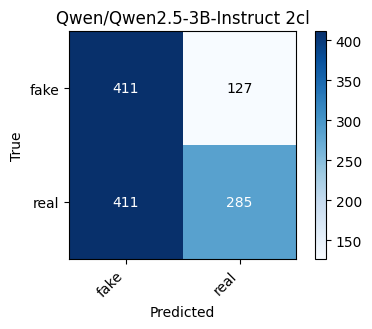


=== Qwen/Qwen2.5-3B-Instruct 6cl ===
accuracy           : 0.1956
balanced accuracy  : 0.2450
precision (macro)  : 0.3600
recall    (macro)  : 0.2450
macro-F1           : 0.1542   weighted-F1: 0.1430
unparsed           : 45 / 1267

              precision    recall  f1-score   support

  pants-fire      0.160     0.722     0.262        90
       false      0.217     0.498     0.303       241
 barely-true      0.118     0.087     0.100       208
   half-true      1.000     0.004     0.008       249
 mostly-true      0.293     0.094     0.143       233
        true      0.371     0.065     0.110       201

    accuracy                          0.196      1222
   macro avg      0.360     0.245     0.154      1222
weighted avg      0.395     0.196     0.143      1222

Confusion matrix:
             pants-fire  false  barely-true  half-true  mostly-true  true
pants-fire           65     21            4          0            0     0
false                91    120           25          0     

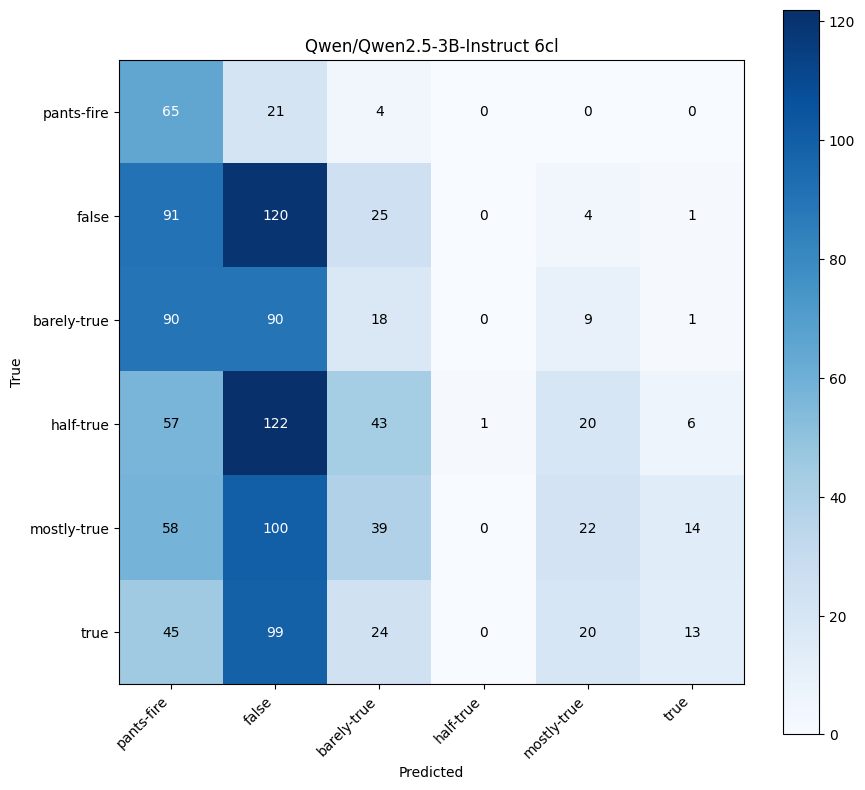

In [15]:
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                            f1_score, balanced_accuracy_score, precision_score, recall_score)
import pandas as pd
import matplotlib.pyplot as plt

for nc, test_df in results.items():
  labels = LABELS_2 if nc == 2 else LABELS_6
  valid = test_df.dropna(subset=["pred"]).copy()
  n_unparsed = len(test_df) - len(valid)
  yt = valid["y_str"].tolist()
  yp = valid["pred"].tolist()

  acc     = accuracy_score(yt, yp)
  bal_acc = balanced_accuracy_score(yt, yp)
  mf1     = f1_score(yt, yp, labels=labels, average="macro", zero_division=0)
  wf1     = f1_score(yt, yp, labels=labels, average="weighted", zero_division=0)
  prec_m  = precision_score(yt, yp, labels=labels, average="macro", zero_division=0)
  rec_m   = recall_score(yt, yp, labels=labels, average="macro", zero_division=0)

  print(f"\n=== {MODEL_ID} {nc}cl ===")
  print(f"accuracy           : {acc:.4f}")
  print(f"balanced accuracy  : {bal_acc:.4f}")
  print(f"precision (macro)  : {prec_m:.4f}")
  print(f"recall    (macro)  : {rec_m:.4f}")
  print(f"macro-F1           : {mf1:.4f}   weighted-F1: {wf1:.4f}")
  print(f"unparsed           : {n_unparsed} / {len(test_df)}")
  print()
  print(classification_report(yt, yp, labels=labels, digits=3, zero_division=0))

  cm = confusion_matrix(yt, yp, labels=labels)
  print("Confusion matrix:")
  print(pd.DataFrame(cm, index=labels, columns=labels))

  fig, ax = plt.subplots(figsize=(1.2*len(labels)+2, 1.2*len(labels)+1))
  im = ax.imshow(cm, cmap="Blues")
  ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
  ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
  for i in range(len(labels)):
      for j in range(len(labels)):
          ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                  color="white" if cm[i,j] > cm.max()/2 else "black")
  ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(f"{MODEL_ID} {nc}cl")
  fig.colorbar(im); fig.tight_layout(); plt.show()